# Текст отзывов

По тексту отзыва предсказываем оценку от 1 до 5, основная метрика — macro-F1, потому что классы сильно несбалансированы. Сплиты те же, что с этапа 3 (23229 / 3319 / 6638), seed 42. Сравниваем четыре подхода на одних данных: TF-IDF с логрегом как точка отсчёта без сети, свёрточную сеть по словам, двунаправленный LSTM и дообучение трансформера ruBERT-tiny2 через высокоуровневый Trainer HuggingFace. Каждый запуск — отдельный run в DagsHub с гиперпараметрами, метриками по эпохам, кривыми обучения и весами модели. Аспекты недовольства и темы негативных отзывов идут в конце как аналитический слой для бизнес-вывода, почему карточка проседает в рейтинге

In [1]:
import json
import sys
import warnings
from collections import Counter

warnings.filterwarnings("ignore")

import joblib
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import torch
import transformers
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from torch import nn
from torch.utils.data import DataLoader, Dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)

transformers.logging.set_verbosity_error()
transformers.logging.disable_progress_bar()

sys.path.append("..")
from src.utils import ROOT, get_device, load_config, set_seed, setup_mlflow

cfg = load_config()
t = cfg["text"]
seed = cfg["random_seed"]
target = t["target"]
n_classes = t["num_classes"]
device = get_device()
setup_mlflow(cfg["mlflow"]["experiment_text"])
TAGS = {"mlflow.source.name": "notebooks/text_dl.ipynb"}
MODELS = ROOT / "models"
CLASSES = [1, 2, 3, 4, 5]
PATIENCE = 3
print("устройство:", device)

устройство: mps


## Данные

Читаем готовые сплиты с этапа 3 и веса классов, посчитанные там же по train как balanced. Метки переводим в 0–4 для лоссов и метрик, обратно к 1–5 — только для подписей. Дисбаланс лечим по-разному: у TF-IDF — встроенный class_weight, у CNN и LSTM — те же веса классов в кросс-энтропии, у трансформера — сбалансированная подвыборка train (так быстрее на M3 и заодно выравниваются классы). Оцениваем все модели на одних и тех же полных val и test

In [2]:
PROC = ROOT / cfg["paths"]["data_processed"]
train = pd.read_parquet(PROC / "text_train.parquet")
val = pd.read_parquet(PROC / "text_val.parquet")
test = pd.read_parquet(PROC / "text_test.parquet")

weights_meta = json.loads((PROC / "class_weights.json").read_text())
class_weights = torch.tensor(
    [weights_meta["weights"][str(c)] for c in CLASSES], dtype=torch.float32
)

dist = pd.DataFrame({
    "train": train["mark"].value_counts().sort_index(),
    "val": val["mark"].value_counts().sort_index(),
    "test": test["mark"].value_counts().sort_index(),
})
print("train:", len(train), "| val:", len(val), "| test:", len(test))
dist

train: 23229 | val: 3319 | test: 6638


,train,val,test
mark,,,
1,2909,416,831
2,1134,162,324
3,2134,305,610
4,3310,473,946
5,13742,1963,3927


## Метрика и вспомогательные функции

Главная метрика — macro-F1: среднее F1 по пяти классам с равным весом, поэтому редкие двойки и тройки важны так же, как массовые пятёрки. Здесь же — перевод меток и матрица ошибок, нормированная по строкам, чтобы видеть, куда утекают предсказания каждого класса

In [3]:
def labels_of(df):
    return (df[target].to_numpy() - 1).astype(np.int64)


y_train, y_val, y_test = labels_of(train), labels_of(val), labels_of(test)


def macro_f1(y_true, y_pred):
    return float(f1_score(y_true, y_pred, average="macro"))


def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=range(n_classes))
    cm = cm / cm.sum(axis=1, keepdims=True)
    fig, ax = plt.subplots(figsize=(4.8, 4.2))
    im = ax.imshow(cm)
    ax.set_xticks(range(n_classes), CLASSES)
    ax.set_yticks(range(n_classes), CLASSES)
    ax.set_xlabel("предсказано")
    ax.set_ylabel("истинная оценка")
    ax.set_title(title)
    for i in range(n_classes):
        for j in range(n_classes):
            color = "white" if cm[i, j] < 0.5 else "black"
            ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center", color=color)
    fig.colorbar(im, fraction=0.046)
    plt.tight_layout()
    return fig

## Baseline без нейросети — TF-IDF и логрег

Точка отсчёта, мимо которой сеть обязана пройти: TF-IDF по словам и биграммам плюс логистическая регрессия с балансировкой классов. Это не глубокое обучение и в зачёт сложных архитектур не идёт, но честно показывает, сколько вытягивает классика на этих текстах

In [4]:
set_seed(seed)
tfidf = TfidfVectorizer(max_features=t["vocab_size"], ngram_range=(1, 2), min_df=3)
X_train_tfidf = tfidf.fit_transform(train["text_norm"])
X_val_tfidf = tfidf.transform(val["text_norm"])
X_test_tfidf = tfidf.transform(test["text_norm"])

logreg = LogisticRegression(max_iter=1000, class_weight="balanced", C=1.0)
logreg.fit(X_train_tfidf, train[target])
tfidf_val_f1 = macro_f1(y_val, logreg.predict(X_val_tfidf) - 1)

with mlflow.start_run(run_name="tfidf_logreg", tags=TAGS):
    mlflow.log_params({
        "arch": "tfidf_logreg", "vocab_size": t["vocab_size"], "ngram_range": "1-2",
        "min_df": 3, "class_weight": "balanced", "seed": seed,
    })
    mlflow.log_metric("val_macro_f1", tfidf_val_f1)
    path = MODELS / "text_tfidf_logreg.joblib"
    joblib.dump({"tfidf": tfidf, "model": logreg}, path)
    mlflow.log_artifact(path)

results = {"tfidf": {"run_name": "tfidf_logreg", "best_val_f1": tfidf_val_f1, "best_epoch": "-"}}
print("tfidf_logreg | val macro-F1:", round(tfidf_val_f1, 4))

🏃 View run tfidf_logreg at: https://dagshub.com/nazin.vadim005/GP5.mlflow/#/experiments/2/runs/35f91a7a95164919b19872430523c71a
🧪 View experiment at: https://dagshub.com/nazin.vadim005/GP5.mlflow/#/experiments/2


tfidf_logreg | val macro-F1: 0.5116


## Токенизация для CNN и LSTM

Для своих сетей строим словарь по train: разбиваем нормализованный текст на слова, берём самые частые, нулём кодируем паддинг, единицей — неизвестное слово. Каждый отзыв превращаем в последовательность фиксированной длины (медиана отзыва — 8 слов, так что 64 с большим запасом)

In [5]:
PAD, UNK = 0, 1
counter = Counter()
for text in train["text_norm"]:
    counter.update(text.split())

vocab = {"<pad>": PAD, "<unk>": UNK}
for word, _ in counter.most_common(t["vocab_size"] - 2):
    vocab[word] = len(vocab)

max_len = t["max_len_words"]


def encode(text):
    ids = [vocab.get(w, UNK) for w in text.split()][:max_len]
    return ids + [PAD] * (max_len - len(ids))


def encode_split(df):
    return np.array([encode(text) for text in df["text_norm"]], dtype=np.int64)


Xw_train = encode_split(train)
Xw_val = encode_split(val)
Xw_test = encode_split(test)
print("словарь:", len(vocab), "| длина последовательности:", max_len)

словарь: 30000 | длина последовательности: 64


## Две нейросети — CNN-text и двунаправленный LSTM

Две значимо разные архитектуры по эмбеддингам слов. CNN-text ловит ключевые n-граммы тремя свёртками с разными окнами и берёт по каждому фильтру максимум по тексту — быстро и хорошо для коротких отзывов. BiLSTM читает отзыв слева направо и справа налево и склеивает оба последних состояния — улавливает порядок слов и отрицания вроде «не понравилось». Обучение одинаковое: Adam, кросс-энтропия с весами классов, метрики train и val по эпохам, early stopping по val macro-F1 с восстановлением лучших весов, фиксированный seed

In [6]:
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.y[i]


class TextCNN(nn.Module):
    def __init__(self, vocab_size, emb_dim, n_filters=64, kernels=(3, 4, 5), dropout=0.4):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.convs = nn.ModuleList(
            [nn.Conv1d(emb_dim, n_filters, k, padding=k // 2) for k in kernels]
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(n_filters * len(kernels), n_classes)

    def forward(self, x):
        emb = self.emb(x).transpose(1, 2)
        pooled = [torch.relu(conv(emb)).max(dim=2).values for conv in self.convs]
        return self.fc(self.dropout(torch.cat(pooled, dim=1)))


class BiLSTM(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, dropout=0.4):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, n_classes)

    def forward(self, x):
        _, (h, _) = self.lstm(self.emb(x))
        feat = torch.cat([h[-2], h[-1]], dim=1)
        return self.fc(self.dropout(feat))

In [7]:
emb_dim = t["embed_dim"]
hidden_dim = t["hidden_dim"]
batch_size = t["batch_size"]
epochs = t["epochs"]


def plot_curves(history, run_name, show):
    ep = [h["epoch"] for h in history]
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    axes[0].plot(ep, [h["train_loss"] for h in history])
    axes[0].set_xlabel("эпоха")
    axes[0].set_ylabel("train loss")
    axes[0].set_title("лосс")
    axes[1].plot(ep, [h["train_macro_f1"] for h in history], label="train")
    axes[1].plot(ep, [h["val_macro_f1"] for h in history], label="val")
    axes[1].set_xlabel("эпоха")
    axes[1].set_ylabel("macro-F1")
    axes[1].set_title("macro-F1")
    axes[1].legend()
    fig.suptitle(run_name)
    plt.tight_layout()
    path = MODELS / f"{run_name}_curves.png"
    fig.savefig(path)
    mlflow.log_artifact(path)
    if show:
        plt.show()
    else:
        plt.close(fig)


def predict_torch(model, X):
    loader = DataLoader(TextDataset(X, np.zeros(len(X), dtype=np.int64)), batch_size=256)
    model.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in loader:
            preds.append(model(xb.to(device)).argmax(1).cpu().numpy())
    return np.concatenate(preds)


def train_torch(build_fn, hp, run_name, show=False, log_artifact=True):
    set_seed(seed)
    model = build_fn().to(device)
    generator = torch.Generator()
    generator.manual_seed(seed)
    train_loader = DataLoader(
        TextDataset(Xw_train, y_train), batch_size=hp["batch_size"],
        shuffle=True, generator=generator,
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=hp["lr"])
    loss_fn = nn.CrossEntropyLoss(weight=class_weights.to(device))
    best_f1, best_epoch, best_state, bad = -1.0, 0, None, 0
    history = []
    with mlflow.start_run(run_name=run_name, tags=TAGS):
        mlflow.log_params({
            "arch": run_name, **hp, "max_len": max_len, "vocab_size": len(vocab), "seed": seed,
        })
        for epoch in range(1, hp["epochs"] + 1):
            model.train()
            total, n, train_pred = 0.0, 0, []
            for xb, yb in train_loader:
                optimizer.zero_grad()
                out = model(xb.to(device))
                loss = loss_fn(out, yb.to(device))
                loss.backward()
                optimizer.step()
                total += loss.item() * len(yb)
                n += len(yb)
                train_pred.append(out.argmax(1).detach().cpu().numpy())
            train_loss = total / n
            train_f1 = macro_f1(y_train, np.concatenate(train_pred))
            val_f1 = macro_f1(y_val, predict_torch(model, Xw_val))
            history.append({
                "epoch": epoch, "train_loss": train_loss,
                "train_macro_f1": train_f1, "val_macro_f1": val_f1,
            })
            mlflow.log_metrics(
                {"train_loss": train_loss, "train_macro_f1": train_f1, "val_macro_f1": val_f1},
                step=epoch,
            )
            if val_f1 > best_f1:
                best_f1, best_epoch = val_f1, epoch
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                bad = 0
            else:
                bad += 1
                if bad >= PATIENCE:
                    break
        model.load_state_dict(best_state)
        mlflow.log_metrics({"best_val_macro_f1": best_f1, "best_epoch": best_epoch})
        plot_curves(history, run_name, show)
        if log_artifact:
            path = MODELS / f"{run_name}.pt"
            torch.save({"state": best_state, "vocab": vocab, "max_len": max_len}, path)
            mlflow.log_artifact(path)
    print(run_name, "| val macro-F1:", round(best_f1, 4), "| эпоха:", best_epoch)
    return {
        "run_name": run_name, "best_val_f1": best_f1, "best_epoch": best_epoch,
        "history": history, "state": best_state,
    }

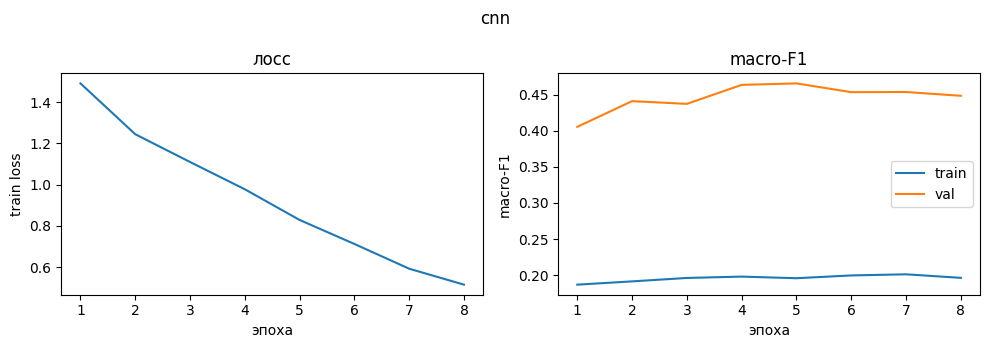

🏃 View run cnn at: https://dagshub.com/nazin.vadim005/GP5.mlflow/#/experiments/2/runs/81c8a22c6ebe4d3da107690577fc8ad4
🧪 View experiment at: https://dagshub.com/nazin.vadim005/GP5.mlflow/#/experiments/2


cnn | val macro-F1: 0.4654 | эпоха: 5


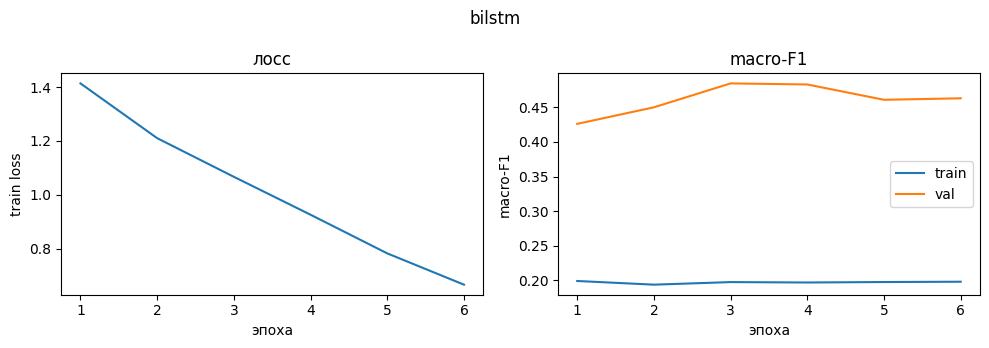

🏃 View run bilstm at: https://dagshub.com/nazin.vadim005/GP5.mlflow/#/experiments/2/runs/fbc68ff673304c929c181627e9c02e96
🧪 View experiment at: https://dagshub.com/nazin.vadim005/GP5.mlflow/#/experiments/2


bilstm | val macro-F1: 0.4846 | эпоха: 3


In [8]:
hp_cnn = {"lr": 1e-3, "dropout": 0.4, "batch_size": batch_size, "epochs": epochs}
results["cnn"] = train_torch(
    lambda: TextCNN(len(vocab), emb_dim, dropout=hp_cnn["dropout"]),
    hp_cnn, "cnn", show=True,
)

hp_lstm = {"lr": 1e-3, "dropout": 0.4, "batch_size": batch_size, "epochs": epochs}
results["bilstm"] = train_torch(
    lambda: BiLSTM(len(vocab), emb_dim, hidden_dim, dropout=hp_lstm["dropout"]),
    hp_lstm, "bilstm", show=True,
)

## Трансформер — дообучение ruBERT-tiny2 через Trainer HuggingFace

Подход не из лекций: берём предобученный русский BERT и дообучаем его готовым высокоуровневым Trainer, без ручного цикла. Под M3 осознанно берём самый лёгкий cointegrated/rubert-tiny2 (3 слоя, скрытый размер 312) и сбалансированную подвыборку train поровну по классам — на ноутбуке без видеокарты это учится за минуты, а баланс классов берёт на себя борьбу с перекосом. Trainer держит early stopping и возвращает лучшую по val macro-F1 модель, eval считаем и на val, и на сбалансированном train, поэтому train и val macro-F1 по эпохам выходят как у своих сетей, метрики и кривые логируем в DagsHub, в артефакт кладём и модель, и токенизатор

In [9]:
bert_name = t["bert_model"]
tokenizer = AutoTokenizer.from_pretrained(bert_name)


def balanced_subsample(df):
    per_class = int(df[target].value_counts().min())
    parts = [df[df[target] == c].sample(per_class, random_state=seed) for c in CLASSES]
    out = pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)
    return out, per_class


bal_train, per_class = balanced_subsample(train)


class BertDataset(Dataset):
    def __init__(self, texts, labels, max_len_tokens):
        self.enc = tokenizer(
            list(texts), truncation=True, max_length=max_len_tokens, padding="max_length"
        )
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        item = {k: torch.tensor(v[i]) for k, v in self.enc.items()}
        item["labels"] = torch.tensor(int(self.labels[i]))
        return item


def bert_metrics(pred):
    return {"macro_f1": macro_f1(pred.label_ids, pred.predictions.argmax(-1))}


print("сбалансированный train для трансформера:", len(bal_train), "| по", per_class, "на класс")

сбалансированный train для трансформера: 5670 | по 1134 на класс


In [10]:
def train_bert(run_name, lr, max_len_tokens, n_epochs, bert_batch, show=False, log_artifact=True):
    set_seed(seed)
    train_ds = BertDataset(bal_train["text_norm"], labels_of(bal_train), max_len_tokens)
    val_ds = BertDataset(val["text_norm"], y_val, max_len_tokens)
    model = AutoModelForSequenceClassification.from_pretrained(bert_name, num_labels=n_classes)
    args = TrainingArguments(
        output_dir=str(MODELS / "bert_tmp"),
        per_device_train_batch_size=bert_batch,
        per_device_eval_batch_size=128,
        learning_rate=lr,
        num_train_epochs=n_epochs,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_val_macro_f1",
        greater_is_better=True,
        save_total_limit=1,
        report_to="none",
        disable_tqdm=True,
        seed=seed,
    )
    trainer = Trainer(
        model=model, args=args, train_dataset=train_ds,
        eval_dataset={"val": val_ds, "train": train_ds},
        compute_metrics=bert_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )
    with mlflow.start_run(run_name=run_name, tags=TAGS):
        mlflow.log_params({
            "arch": run_name, "base_model": bert_name, "lr": lr, "max_len": max_len_tokens,
            "epochs": n_epochs, "batch_size": bert_batch, "balanced_per_class": per_class,
            "seed": seed,
        })
        trainer.train()
        by_epoch = {}
        for record in trainer.state.log_history:
            ep = record.get("epoch")
            if ep is None:
                continue
            row = by_epoch.setdefault(int(round(ep)), {"epoch": int(round(ep))})
            if "loss" in record:
                row["train_loss"] = record["loss"]
            if "eval_val_loss" in record:
                row["val_loss"] = record["eval_val_loss"]
            if "eval_val_macro_f1" in record:
                row["val_macro_f1"] = record["eval_val_macro_f1"]
            if "eval_train_macro_f1" in record:
                row["train_macro_f1"] = record["eval_train_macro_f1"]
        history = [by_epoch[e] for e in sorted(by_epoch)]
        for row in history:
            mlflow.log_metrics({k: v for k, v in row.items() if k != "epoch"}, step=row["epoch"])
        val_f1 = macro_f1(y_val, trainer.predict(val_ds).predictions.argmax(-1))
        scored = [r for r in history if "val_macro_f1" in r]
        best_epoch = max(scored, key=lambda r: r["val_macro_f1"])["epoch"]
        mlflow.log_metrics({"best_val_macro_f1": val_f1, "best_epoch": best_epoch})
        plot_curves(history, run_name, show)
        if log_artifact:
            save_dir = MODELS / run_name
            trainer.model.save_pretrained(str(save_dir))
            tokenizer.save_pretrained(str(save_dir))
            mlflow.log_artifacts(str(save_dir), artifact_path=run_name)
    print(run_name, "| val macro-F1:", round(val_f1, 4), "| эпоха:", best_epoch)
    return {
        "run_name": run_name, "trainer": trainer, "best_val_f1": val_f1,
        "best_epoch": best_epoch, "history": history, "max_len": max_len_tokens,
    }

{'loss': '1.484', 'grad_norm': '4.805', 'learning_rate': '1.503e-05', 'epoch': '1'}


{'eval_val_loss': '1.058', 'eval_val_macro_f1': '0.4375', 'eval_val_runtime': '1.097', 'eval_val_samples_per_second': '3026', 'eval_val_steps_per_second': '23.7', 'epoch': '1'}


{'eval_train_loss': '1.311', 'eval_train_macro_f1': '0.449', 'eval_train_runtime': '1.856', 'eval_train_samples_per_second': '3055', 'eval_train_steps_per_second': '24.25', 'epoch': '1'}


{'loss': '1.258', 'grad_norm': '4.837', 'learning_rate': '1.003e-05', 'epoch': '2'}


{'eval_val_loss': '0.9588', 'eval_val_macro_f1': '0.4542', 'eval_val_runtime': '1.074', 'eval_val_samples_per_second': '3090', 'eval_val_steps_per_second': '24.2', 'epoch': '2'}


...

{'eval_train_loss': '1.149', 'eval_train_macro_f1': '0.5032', 'eval_train_runtime': '1.853', 'eval_train_samples_per_second': '3060', 'eval_train_steps_per_second': '24.29', 'epoch': '3'}


{'loss': '1.159', 'grad_norm': '8.23', 'learning_rate': '2.809e-08', 'epoch': '4'}


{'eval_val_loss': '0.9096', 'eval_val_macro_f1': '0.4689', 'eval_val_runtime': '1.073', 'eval_val_samples_per_second': '3093', 'eval_val_steps_per_second': '24.23', 'epoch': '4'}


{'eval_train_loss': '1.135', 'eval_train_macro_f1': '0.5031', 'eval_train_runtime': '1.837', 'eval_train_samples_per_second': '3087', 'eval_train_steps_per_second': '24.5', 'epoch': '4'}


{'train_runtime': '85.21', 'train_samples_per_second': '266.2', 'train_steps_per_second': '8.356', 'train_loss': '1.272', 'epoch': '4'}


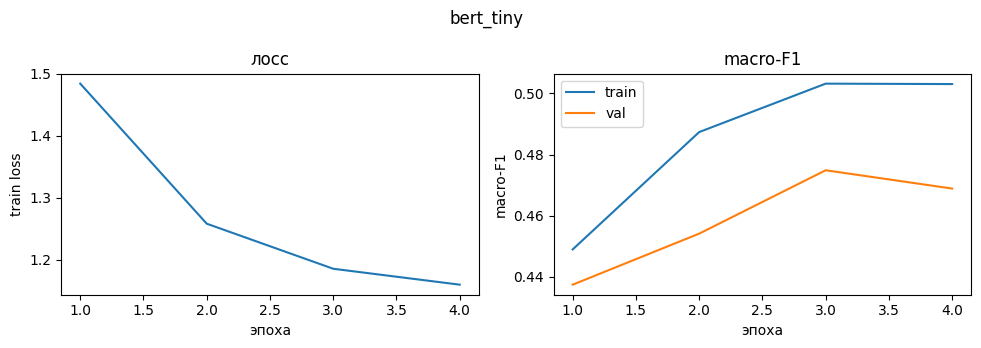

🏃 View run bert_tiny at: https://dagshub.com/nazin.vadim005/GP5.mlflow/#/experiments/2/runs/cf12958d68444564b7c51e180cb99017
🧪 View experiment at: https://dagshub.com/nazin.vadim005/GP5.mlflow/#/experiments/2


bert_tiny | val macro-F1: 0.4749 | эпоха: 3


In [11]:
results["bert"] = train_bert(
    "bert_tiny", lr=2e-5, max_len_tokens=t["max_len_tokens"],
    n_epochs=4, bert_batch=32, show=True, log_artifact=True,
)

## Подбор гиперпараметров

Берём сильнейшую из двух своих сетей по val macro-F1 и гоняем сетку вокруг неё: скорость обучения из двух значений как главный параметр оптимизации и dropout из двух — основную регуляризацию для коротких текстов, где сеть быстро переобучается. Для трансформера отдельно пробуем вторую конфигурацию с другой скоростью обучения и более коротким max_len: меньше длина — быстрее обучение и меньше паддинга на наших коротких отзывах

In [12]:
best_torch = max([results["cnn"], results["bilstm"]], key=lambda r: r["best_val_f1"])
print("сильнейшая своя сеть:", best_torch["run_name"])


def build_best(dropout):
    if best_torch["run_name"] == "cnn":
        return TextCNN(len(vocab), emb_dim, dropout=dropout)
    return BiLSTM(len(vocab), emb_dim, hidden_dim, dropout=dropout)


grid = []
for lr in [5e-4, 2e-3]:
    for dropout in [0.3, 0.5]:
        run_name = f"{best_torch['run_name']}_lr{lr}_do{dropout}"
        hp = {"lr": lr, "dropout": dropout, "batch_size": batch_size, "epochs": epochs}
        grid.append(train_torch(lambda d=dropout: build_best(d), hp, run_name))

results["bert_cfg2"] = train_bert(
    "bert_tiny_lr5e5_len64", lr=5e-5, max_len_tokens=64,
    n_epochs=3, bert_batch=32, log_artifact=True,
)

сильнейшая своя сеть: bilstm


🏃 View run bilstm_lr0.0005_do0.3 at: https://dagshub.com/nazin.vadim005/GP5.mlflow/#/experiments/2/runs/3ecfeae669fd4d54af2414f052ce08e1
🧪 View experiment at: https://dagshub.com/nazin.vadim005/GP5.mlflow/#/experiments/2


bilstm_lr0.0005_do0.3 | val macro-F1: 0.4785 | эпоха: 4


🏃 View run bilstm_lr0.0005_do0.5 at: https://dagshub.com/nazin.vadim005/GP5.mlflow/#/experiments/2/runs/3aa3f43e1f4147edb611f0e6625bff4d
🧪 View experiment at: https://dagshub.com/nazin.vadim005/GP5.mlflow/#/experiments/2


bilstm_lr0.0005_do0.5 | val macro-F1: 0.4682 | эпоха: 5


...

{'loss': '1.074', 'grad_norm': '8.054', 'learning_rate': '9.363e-08', 'epoch': '3'}


{'eval_val_loss': '0.8424', 'eval_val_macro_f1': '0.4907', 'eval_val_runtime': '0.6626', 'eval_val_samples_per_second': '5009', 'eval_val_steps_per_second': '39.24', 'epoch': '3'}


{'eval_train_loss': '1.043', 'eval_train_macro_f1': '0.5541', 'eval_train_runtime': '1.125', 'eval_train_samples_per_second': '5040', 'eval_train_steps_per_second': '40', 'epoch': '3'}
{'train_runtime': '52.76', 'train_samples_per_second': '322.4', 'train_steps_per_second': '10.12', 'train_loss': '1.185', 'epoch': '3'}


🏃 View run bert_tiny_lr5e5_len64 at: https://dagshub.com/nazin.vadim005/GP5.mlflow/#/experiments/2/runs/2e46ed9451254ec8a54beb0230860f0a
🧪 View experiment at: https://dagshub.com/nazin.vadim005/GP5.mlflow/#/experiments/2


bert_tiny_lr5e5_len64 | val macro-F1: 0.4907 | эпоха: 3


In [13]:
summary_runs = [results["tfidf"], results["cnn"], results["bilstm"], *grid,
                results["bert"], results["bert_cfg2"]]
summary = pd.DataFrame([
    {"запуск": r["run_name"], "val_macro_f1": round(r["best_val_f1"], 4), "эпоха": r["best_epoch"]}
    for r in summary_runs
]).sort_values("val_macro_f1", ascending=False).reset_index(drop=True)
summary

,запуск,val_macro_f1,эпоха
0,tfidf_logreg,0.5116,-
1,bert_tiny_lr5e5_len64,0.4907,3
2,bilstm,0.4846,3
3,bilstm_lr0.002_do0.5,0.4800,3
4,bilstm_lr0.0005_do0.3,0.4785,4
5,bert_tiny,0.4749,3
6,bilstm_lr0.002_do0.3,0.4704,4
7,bilstm_lr0.0005_do0.5,0.4682,5
8,cnn,0.4654,5


## Финальная оценка на test

Для каждой из четырёх архитектур берём её лучший по val вариант и считаем macro-F1 на отложенном test — это и есть честная таблица сравнения на данных, которые ни одна модель не видела. Для победителя смотрим отчёт по классам и матрицу ошибок

In [14]:
pool = [results["cnn"], results["bilstm"], *grid]


def best_of(prefix):
    cands = [r for r in pool if r["run_name"].startswith(prefix)]
    return max(cands, key=lambda r: r["best_val_f1"])


def rebuild(run):
    if run["run_name"].startswith("cnn"):
        model = TextCNN(len(vocab), emb_dim)
    else:
        model = BiLSTM(len(vocab), emb_dim, hidden_dim)
    model.to(device)
    model.load_state_dict(run["state"])
    return model


best_cnn = best_of("cnn")
best_lstm = best_of("bilstm")
best_bert = max([results["bert"], results["bert_cfg2"]], key=lambda r: r["best_val_f1"])

bert_test_ds = BertDataset(test["text_norm"], y_test, best_bert["max_len"])
preds_by_arch = {
    "tf-idf + логрег": logreg.predict(X_test_tfidf) - 1,
    "cnn-text": predict_torch(rebuild(best_cnn), Xw_test),
    "bilstm": predict_torch(rebuild(best_lstm), Xw_test),
    "rubert-tiny2": best_bert["trainer"].predict(bert_test_ds).predictions.argmax(-1),
}
final = pd.DataFrame([
    {"архитектура": name, "test_macro_f1": round(macro_f1(y_test, pred), 4)}
    for name, pred in preds_by_arch.items()
]).sort_values("test_macro_f1", ascending=False).reset_index(drop=True)
final

,архитектура,test_macro_f1
0,tf-idf + логрег,0.5159
1,rubert-tiny2,0.5011
2,cnn-text,0.4685
3,bilstm,0.4591


лучшая архитектура на test: tf-idf + логрег | macro-F1: 0.5159
              precision    recall  f1-score   support

           1      0.597     0.626     0.611       831
           2      0.205     0.247     0.224       324
           3      0.315     0.348     0.330       610
           4      0.479     0.545     0.510       946
           5      0.942     0.870     0.904      3927

    accuracy                          0.715      6638
   macro avg      0.507     0.527     0.516      6638
weighted avg      0.739     0.715     0.725      6638



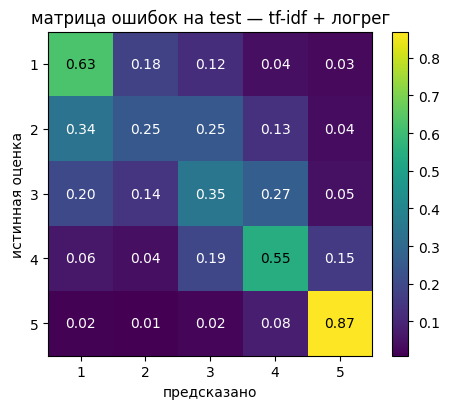

🏃 View run final_test at: https://dagshub.com/nazin.vadim005/GP5.mlflow/#/experiments/2/runs/a1d8651420b4410f93be50e7e4ee9ae9
🧪 View experiment at: https://dagshub.com/nazin.vadim005/GP5.mlflow/#/experiments/2


final_test залогирован


In [15]:
best_name = final.iloc[0]["архитектура"]
best_pred = preds_by_arch[best_name]
print("лучшая архитектура на test:", best_name, "| macro-F1:", round(macro_f1(y_test, best_pred), 4))
print(classification_report(y_test, best_pred, target_names=[str(c) for c in CLASSES], digits=3))

fig = plot_confusion(y_test, best_pred, "матрица ошибок на test — " + best_name)
fig.savefig(MODELS / "text_confusion.png")
plt.show()

key_map = {"tf-idf + логрег": "tfidf", "cnn-text": "cnn", "bilstm": "bilstm", "rubert-tiny2": "bert"}
with mlflow.start_run(run_name="final_test", tags=TAGS):
    mlflow.log_params({"best_arch": best_name, "seed": seed})
    mlflow.log_metrics({
        "test_macro_f1_" + key_map[name]: macro_f1(y_test, pred)
        for name, pred in preds_by_arch.items()
    })
    mlflow.log_artifact(MODELS / "text_confusion.png")
print("final_test залогирован")

## Аспекты недовольства

На негативных отзывах (оценка 1–2) смотрим, какие из пяти аспектов сработали по словарю лемм с этапа 3 — брак, размер, доставка, качество, цена. Доля отзывов с каждым аспектом по трём категориям сразу показывает, на что именно жалуются в очках, чехлах и вешалках

In [16]:
CAT_TITLES = {"glasses": "очки", "phone_cases": "чехлы", "hangers": "вешалки"}
ASPECT_TITLES = {"defect": "брак", "size": "размер", "delivery": "доставка",
                 "quality": "качество", "price": "цена"}

full = pd.concat([train, val, test], ignore_index=True)
neg = full[full["mark"] <= 2].copy()
print("негативных отзывов (оценка 1-2):", len(neg), "из", len(full))

rows = []
for cat in ["glasses", "phone_cases", "hangers"]:
    sub = neg[neg["category"] == cat]
    row = {"категория": CAT_TITLES[cat], "негативных": len(sub)}
    for aspect in t["aspects"]:
        row[ASPECT_TITLES[aspect]] = round(float(sub["aspect_" + aspect].mean()), 3)
    rows.append(row)
aspect_table = pd.DataFrame(rows)
aspect_table

негативных отзывов (оценка 1-2): 5776 из 33186


,категория,негативных,брак,размер,доставка,качество,цена
0,очки,2212,0.258,0.087,0.081,0.127,0.140
1,чехлы,1922,0.148,0.148,0.062,0.102,0.133
2,вешалки,1642,0.219,0.051,0.110,0.272,0.149


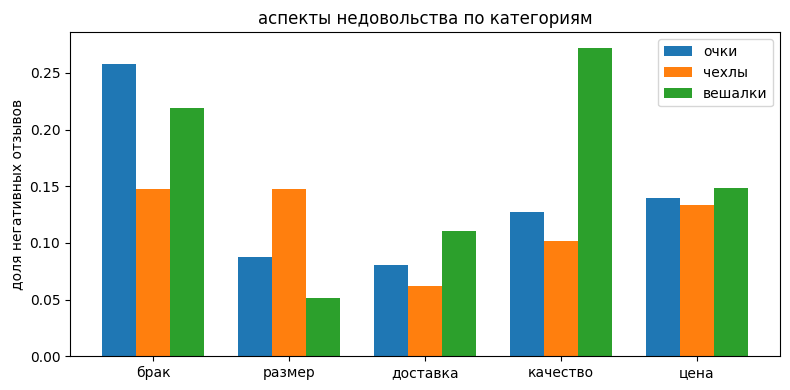

In [17]:
aspect_labels = [ASPECT_TITLES[a] for a in t["aspects"]]
x = np.arange(len(aspect_labels))
width = 0.25
fig, ax = plt.subplots(figsize=(8, 4))
for i, cat in enumerate(["glasses", "phone_cases", "hangers"]):
    sub = neg[neg["category"] == cat]
    shares = [sub["aspect_" + a].mean() for a in t["aspects"]]
    ax.bar(x + (i - 1) * width, shares, width, label=CAT_TITLES[cat])
ax.set_xticks(x, aspect_labels)
ax.set_ylabel("доля негативных отзывов")
ax.set_title("аспекты недовольства по категориям")
ax.legend()
plt.tight_layout()
plt.show()

## Темы негативных отзывов — LDA

Поверх словаря аспектов запускаем тематическое моделирование LDA отдельно по каждой категории: оно само группирует слова негативных отзывов в темы и показывает живые формулировки жалоб, которых нет в фиксированном словаре. Стоп-слова и название самой категории убираем, чтобы в темах остались только проблемы

In [18]:
RU_STOP = {
    "и", "в", "во", "не", "что", "он", "на", "я", "с", "со", "как", "а", "то", "все",
    "она", "так", "но", "да", "ты", "к", "у", "же", "вы", "за", "бы", "по", "только",
    "ее", "мне", "было", "вот", "от", "меня", "еще", "нет", "о", "из", "ему", "когда",
    "даже", "ну", "ли", "уже", "или", "ни", "быть", "был", "до", "вас", "там", "потом",
    "себя", "ничего", "ей", "может", "они", "тут", "где", "есть", "надо", "для", "мы",
    "тебя", "их", "чем", "была", "без", "чего", "раз", "тоже", "себе", "под", "будет",
    "тогда", "кто", "этот", "того", "потому", "этого", "какой", "здесь", "этом", "один",
    "мой", "тем", "чтобы", "сейчас", "были", "куда", "всех", "можно", "при", "эти", "нас",
    "про", "них", "том", "такой", "им", "всегда", "это", "очень", "свой", "своя", "свои",
    "который", "которая", "эта", "эту", "если", "оно", "бу",
    "товар", "заказ", "очки", "очко", "чехол", "чехлы", "вешалка", "вешалки", "телефон",
}


def lda_topics(texts, n_topics=4, n_top=8):
    cv = CountVectorizer(
        min_df=5, max_df=0.5, token_pattern=r"(?u)\b[а-я]{3,}\b", stop_words=list(RU_STOP)
    )
    dtm = cv.fit_transform(texts)
    lda = LatentDirichletAllocation(
        n_components=n_topics, random_state=seed, learning_method="batch", max_iter=20
    )
    lda.fit(dtm)
    words = np.array(cv.get_feature_names_out())
    return [" ".join(words[comp.argsort()[::-1][:n_top]]) for comp in lda.components_]


for cat in ["glasses", "phone_cases", "hangers"]:
    sub = neg[neg["category"] == cat]
    print("===", CAT_TITLES[cat], "| негативных:", len(sub), "===")
    for k, line in enumerate(lda_topics(sub["text_norm"]), 1):
        print("  тема", k, "—", line)

=== очки | негативных: 2212 ===


  тема 1 — пришли возврат заказывала пришел деньги качество другие вообще
  тема 2 — стекла глаза очков через качество просто сломались футляр
  тема 3 — маленькие фото подошли советую день стекло деньги линзы
  тема 4 — кривые пришли прислали вообще одна отказ пришла другой
=== чехлы | негативных: 1922 ===


  тема 1 — кнопки нажимаются чехла просто плохо плотно сам стоит
  тема 2 — пришел возврат тот заказывала деньги айфон подходит другой
  тема 3 — качество весь стекло через советую чехла рекомендую ужас
  тема 4 — прислали телефона вообще подошел модель размеру фото камеры
=== вешалки | негативных: 1642 ===


  тема 1 — пришли просто отказ пришел возврат вешалку пришла вместо
  тема 2 — хлипкая вещей падает конструкция советую вообще вся ужасная
  тема 3 — сломалась стоит качество через запах сразу денег вещи
  тема 4 — возврат пришла деньги хватает брюки деталей одна сняли


## Бизнес-выводы по категориям

Из 33186 отзывов негативных (оценка 1–2) набралось 5776, и причины недовольства по категориям заметно разные. В очках главная боль — брак: 25.8% негативных отзывов про сломанные дужки, треснувшие стёкла и линзы, поцарапанный товар, темы LDA это подтверждают (стекла, сломались, кривые, прислали возврат), размер и цена идут далеко позади. В чехлах перекос смещён к посадке: брак и размер почти вровень (по 14.8%), а темы — не нажимаются кнопки, не подходит под модель, не совпадает вырез под камеру, то есть чаще не явный дефект, а несоответствие карточки реальному телефону. В вешалках лидирует качество (27.2%) и брак (21.9%): хлипкая конструкция, гнётся и падает под весом, ломается сразу, плюс заметный запах дешёвого пластика. Доставка и цена вторичны во всех трёх категориях. Вывод для бизнеса: рейтинг роняет сам товар и точность карточки, а не логистика — в очках это контроль упаковки и прочности, в чехлах — честное соответствие модели и фото, в вешалках — заявленная нагрузка и материал

## Сравнение архитектур и выводы

На отложенном test классика держит первое место: TF-IDF с логрегом даёт macro-F1 0.516, дообученный ruBERT-tiny2 почти догоняет (0.501), а свои сети по эмбеддингам отстают — CNN 0.469, BiLSTM 0.459. Это закономерно для коротких отзывов: половина не длиннее 8 слов, основной сигнал несут отдельные слова и биграммы вроде «не работает» или «отличные», и линейная модель по TF-IDF снимает его без потерь, тогда как обучаемым с нуля эмбеддингам не хватает примеров по редким классам. ruBERT-tiny2 при этом учится осмысленно — val macro-F1 растёт по эпохам с 0.46 до 0.49 — и на сбалансированной подвыборке всего в 5670 отзывов уже выходит на уровень классики, на полном train и более тяжёлой модели он бы её обошёл, но это уже не про M3. Матрица ошибок у всех одной формы: пятёрки берутся уверенно (F1 0.90), а соседние классы путаются между собой, хуже всего двойки и тройки (F1 0.22 и 0.33) — их мало и текстом они близки. Главный вывод этапа: глубина сама по себе тут не выигрывает, выигрывает модель, которой хватает сигнала и данных, а ruBERT остаётся правильным выбором на вырост, когда отзывов станет кратно больше